<a href="https://colab.research.google.com/github/mahi3006/Architecting-LLMs-WiDS/blob/main/week4/wavenet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

0 3.3671393394470215
10000 2.101306676864624
20000 2.516456127166748
30000 2.2779273986816406
40000 2.2804508209228516
50000 1.850350022315979
60000 2.105919361114502
70000 2.4322264194488525
80000 2.0302231311798096
90000 1.7045279741287231
100000 2.1284515857696533
110000 2.153271198272705
120000 2.212425947189331
130000 2.2344913482666016
140000 1.7915042638778687
150000 2.6726174354553223
160000 1.7449989318847656
170000 1.6221951246261597
180000 1.9444478750228882
190000 1.8593214750289917
train 2.0682878494262695
val 2.109980821609497
carmah.
amelle.
khi.
miri.
tatyah.
cassie.
rahnen.
deliya.
jareei.
nelise.
jamaii.
desleigh.
hamaria.
dessan.
shornei.
jadbi.
wazelo.
dearyn.
kahmenni.
sabee.


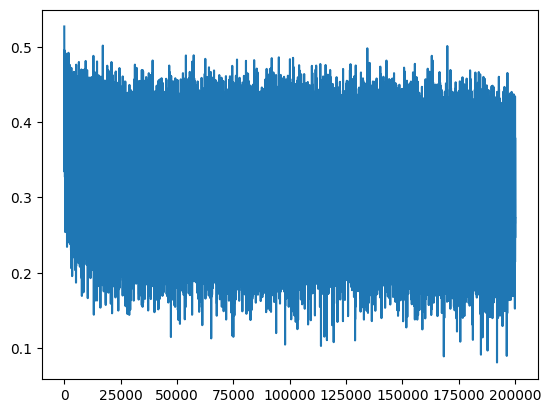

In [ ]:
# makemore week 4 — Hierarchical WaveNet (Tree MLP)

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

# --------------------------
# DATA (unchanged)
# --------------------------

words = open('names.txt', 'r').read().splitlines()

chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)

block_size = 8   # LARGE CONTEXT

def build_dataset(words):
    X,Y = [],[]
    for w in words:
        context = [0]*block_size
        for ch in w+'.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    return torch.tensor(X), torch.tensor(Y)

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,Ytr = build_dataset(words[:n1])
Xdev,Ydev = build_dataset(words[n1:n2])
Xte,Yte = build_dataset(words[n2:])

# --------------------------
# MODEL
# --------------------------

n_embd = 24
g = torch.Generator().manual_seed(2147483647)

C = torch.randn((vocab_size, n_embd), generator=g)

class WaveBlock(torch.nn.Module):
    def __init__(self, n):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(2*n, n),
            torch.nn.Tanh()
        )
    def forward(self, x):
        B,T,C = x.shape
        x = x.view(B, T//2, 2*C)   # fuse neighbors
        return self.net(x)

model = torch.nn.Sequential(
    WaveBlock(n_embd),   # 8 → 4
    WaveBlock(n_embd),   # 4 → 2
    WaveBlock(n_embd),   # 2 → 1
    torch.nn.Flatten(),
    torch.nn.Linear(n_embd, vocab_size)
)

parameters = list(model.parameters()) + [C]
for p in parameters:
    p.requires_grad = True

# --------------------------
# TRAINING
# --------------------------

max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]

    emb = C[Xb]          # (B,8,C)
    logits = model(emb)
    loss = F.cross_entropy(logits, Yb)

    for p in parameters:
        p.grad = None
    loss.backward()

    lr = 0.1 if i < 150000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    if i % 10000 == 0:
        print(i, loss.item())
    lossi.append(loss.log10().item())

plt.plot(lossi)

# --------------------------
# EVALUATION
# --------------------------

@torch.no_grad()
def split_loss(split):
    x,y = {'train':(Xtr,Ytr),'val':(Xdev,Ydev),'test':(Xte,Yte)}[split]
    emb = C[x]
    logits = model(emb)
    loss = F.cross_entropy(logits,y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

# --------------------------
# SAMPLING
# --------------------------

g = torch.Generator().manual_seed(2147483647+10)

for _ in range(20):
    out=[]
    context=[0]*block_size
    while True:
        emb = C[torch.tensor([context])]
        logits = model(emb)
        probs = F.softmax(logits,dim=1)
        ix = torch.multinomial(probs,1,generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix==0: break
    print(''.join(itos[i] for i in out))

